# Exercise: Exploration Strategies
## AIAT 123 - Reinforcement Learning

## Learning Objectives
- Implement epsilon-greedy strategy
- Implement UCB algorithm
- Compare exploration strategies
- Apply to A/B testing

## Real-World Context
You're optimizing ad placement for an e-commerce platform.

## Exercise Brief

This exercise checks whether students can compare exploration strategies in a structured way.

They should not only run the code, but also explain why different strategies behave differently.

Why this matters: Unit 4 is about judgment and interpretation, not only implementation.

This exercise is meant to make students defend what they observe.

## Exercise Goal

In this exercise, you will build a small bandit setup and compare exploration
strategies using reward and regret, not just raw code.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

# Line magic: Jupyter/IPython directive for this line only.
%pip install numpy matplotlib -q
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt
# Print text to the notebook cell output (console).
print('✅ Setup complete!')


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.

✅ Setup complete!


## Task 1: Multi-Armed Bandit (20 points)

Simulate a multi-armed bandit with different ad CTRs.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `MultiArmedBandit` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class MultiArmedBandit:
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, n_arms, true_rewards.
    def __init__(self, n_arms, true_rewards):
        # Assign/update a variable used later in this cell or in other cells.
        self.n_arms = n_arms
        # Assign/update a variable used later in this cell or in other cells.
        self.true_rewards = np.asarray(true_rewards, dtype=float)

    # Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, arm.
    def pull(self, arm):
        # Return a value from this function to its caller.
        return float(np.random.binomial(1, self.true_rewards[arm]))


# Assign/update a variable used later in this cell or in other cells.
bandit = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Print text to the notebook cell output (console).
print("Bandit ready with", bandit.n_arms, "arms")
# Print text to the notebook cell output (console).
print("Task 1 prompt: explain why the true rewards are hidden from the agent.")


Bandit ready with 4 arms
Task 1 prompt: explain why the true rewards are hidden from the agent.


## Task 2: Epsilon-Greedy (25 points)

Implement epsilon-greedy exploration strategy.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, epsilon, n_steps.
def epsilon_greedy(bandit, epsilon=0.1, n_steps=1000):
    # Assign/update a variable used later in this cell or in other cells.
    q = np.zeros(bandit.n_arms)
    # Assign/update a variable used later in this cell or in other cells.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Assign/update a variable used later in this cell or in other cells.
    chosen_actions = []

    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(n_steps):
        # Branch: only run the next indented lines when this condition is true.
        if np.random.rand() < epsilon:
            # Assign/update a variable used later in this cell or in other cells.
            action = np.random.randint(bandit.n_arms)
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Assign/update a variable used later in this cell or in other cells.
            action = int(np.argmax(q))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Assign/update a variable used later in this cell or in other cells.
        n[action] += 1
        # Assign/update a variable used later in this cell or in other cells.
        q[action] += (reward - q[action]) / n[action]
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
        # Append one value to a list (mutates the list in place).
        chosen_actions.append(action)

    # Return a value from this function to its caller.
    return q, np.array(rewards), np.array(chosen_actions)


# Assign/update a variable used later in this cell or in other cells.
q_eg, rewards_eg, actions_eg = epsilon_greedy(bandit, epsilon=0.1, n_steps=500)
# Print text to the notebook cell output (console).
print("epsilon-greedy estimated values:", np.round(q_eg, 3))


epsilon-greedy estimated values: [0.127 0.056 0.261 0.077]


## Task 3: UCB Algorithm (30 points)

Implement Upper Confidence Bound algorithm.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: bandit, c, n_steps.
def ucb(bandit, c=2.0, n_steps=1000):
    # Assign/update a variable used later in this cell or in other cells.
    q = np.zeros(bandit.n_arms)
    # Assign/update a variable used later in this cell or in other cells.
    n = np.zeros(bandit.n_arms)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Assign/update a variable used later in this cell or in other cells.
    chosen_actions = []

    # Loop header: repeat the indented block for each item in the iterable.
    for t in range(1, n_steps + 1):
        # Assign/update a variable used later in this cell or in other cells.
        exploration_bonus = np.full(bandit.n_arms, np.inf)
        # Assign/update a variable used later in this cell or in other cells.
        tried = n > 0
        # Assign/update a variable used later in this cell or in other cells.
        exploration_bonus[tried] = c * np.sqrt(np.log(t + 1) / n[tried])
        # Assign/update a variable used later in this cell or in other cells.
        action = int(np.argmax(q + exploration_bonus))
        # Unpack the one-step model output from transition(state, action).
        reward = bandit.pull(action)
        # Assign/update a variable used later in this cell or in other cells.
        n[action] += 1
        # Assign/update a variable used later in this cell or in other cells.
        q[action] += (reward - q[action]) / n[action]
        # Append one value to a list (mutates the list in place).
        rewards.append(reward)
        # Append one value to a list (mutates the list in place).
        chosen_actions.append(action)

    # Return a value from this function to its caller.
    return q, np.array(rewards), np.array(chosen_actions)


# Assign/update a variable used later in this cell or in other cells.
bandit_ucb = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
# Assign/update a variable used later in this cell or in other cells.
q_ucb, rewards_ucb, actions_ucb = ucb(bandit_ucb, c=2.0, n_steps=500)
# Print text to the notebook cell output (console).
print("UCB estimated values:", np.round(q_ucb, 3))


UCB estimated values: [0.11  0.118 0.316 0.207]


## Task 4: Comparison (25 points)

Compare strategies and analyze results.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


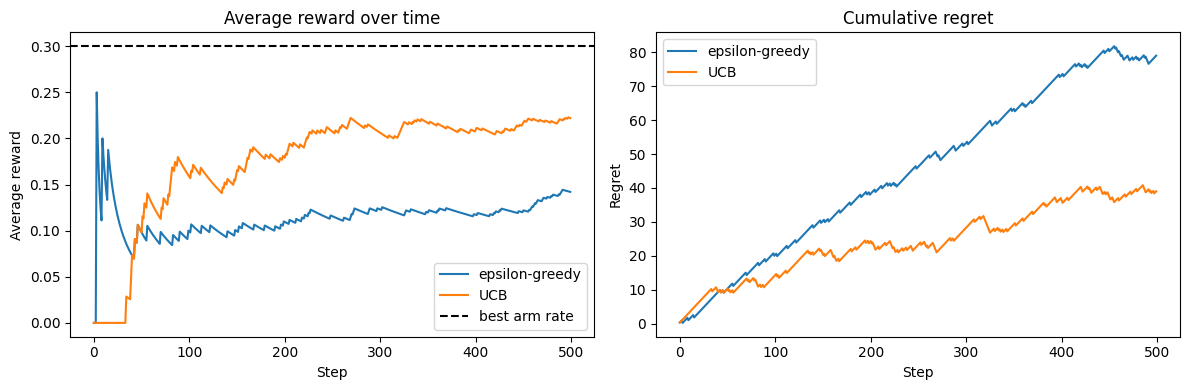

Reflection prompts:
1. Which strategy found the best arm faster?
2. Which strategy accumulated less regret?
3. Why might UCB outperform epsilon-greedy in this setup?


In [5]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `cumulative_average` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: rewards.
def cumulative_average(rewards):
    # Return a value from this function to its caller.
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)


# Function `cumulative_regret` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: true_best_reward, rewards.
def cumulative_regret(true_best_reward, rewards):
    # Return a value from this function to its caller.
    return np.cumsum(true_best_reward - rewards)


# Assign/update a variable used later in this cell or in other cells.
best_possible = np.max(bandit.true_rewards)

# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.figure(figsize=(12, 4))
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1, 2, 1)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(cumulative_average(rewards_eg), label="epsilon-greedy")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(cumulative_average(rewards_ucb), label="UCB")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(best_possible, linestyle="--", color="black", label="best arm rate")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Average reward over time")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Step")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.ylabel("Average reward")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.legend()

# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1, 2, 2)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(cumulative_regret(best_possible, rewards_eg), label="epsilon-greedy")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.plot(cumulative_regret(best_possible, rewards_ucb), label="UCB")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Cumulative regret")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.xlabel("Step")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.ylabel("Regret")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.legend()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.tight_layout()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.show()

# Print text to the notebook cell output (console).
print("Reflection prompts:")
# Print text to the notebook cell output (console).
print("1. Which strategy found the best arm faster?")
# Print text to the notebook cell output (console).
print("2. Which strategy accumulated less regret?")
# Print text to the notebook cell output (console).
print("3. Why might UCB outperform epsilon-greedy in this setup?")


## Submission

**Total: 100 points**

Real-world: A/B testing, ad optimization, recommendation systems

## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Netflix shows different thumbnails to different users and picks the best one using Thompson Sampling — same as this example
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


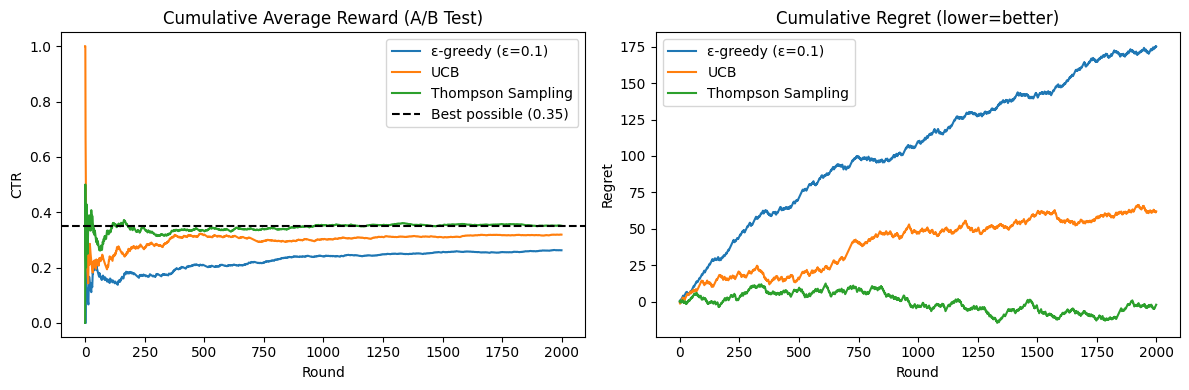


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Import names from a package/module into the notebook kernel namespace.
import numpy as np, matplotlib.pyplot as plt

# Call a NumPy helper (array creation, options, or array conversion).
np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
# Assign/update a variable used later in this cell or in other cells.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
# Assign/update a variable used later in this cell or in other cells.
N_ARMS   = len(TRUE_RATES)
# Assign/update a variable used later in this cell or in other cells.
N_ROUNDS = 2000
# Assign/update a variable used later in this cell or in other cells.
BEST_RATE = max(TRUE_RATES)

# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Assign/update a variable used later in this cell or in other cells.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps else np.argmax(totals / (counts + 1e-9))
        # Append one value to a list (mutates the list in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Return a value from this function to its caller.
    return rewards

# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Assign/update a variable used later in this cell or in other cells.
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for arm in range(N_ARMS):
        # Append one value to a list (mutates the list in place).
        r = pull(arm); counts[arm] = 1; totals[arm] += r; rewards.append(r)
    # Loop header: repeat the indented block for each item in the iterable.
    for t in range(N_ARMS, N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        avg_reward = totals / counts
        # Assign/update a variable used later in this cell or in other cells.
        bonus = np.sqrt(2 * np.log(t + 1) / counts)
        # Assign/update a variable used later in this cell or in other cells.
        arm = int(np.argmax(avg_reward + bonus))
        # Append one value to a list (mutates the list in place).
        r = pull(arm); counts[arm] += 1; totals[arm] += r; rewards.append(r)
    # Return a value from this function to its caller.
    return rewards

# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Assign/update a variable used later in this cell or in other cells.
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    # Loop header: repeat the indented block for each item in the iterable.
    for _ in range(N_ROUNDS):
        # Assign/update a variable used later in this cell or in other cells.
        samples = np.random.beta(alpha, beta_)
        # Assign/update a variable used later in this cell or in other cells.
        arm = np.argmax(samples)
        # Assign/update a variable used later in this cell or in other cells.
        r = pull(arm)
        # Branch: only run the next indented lines when this condition is true.
        if r: alpha[arm] += 1
        # Else branch: runs when the matching if/elif chain was not taken.
        else: beta_[arm] += 1
        # Append one value to a list (mutates the list in place).
        rewards.append(r)
    # Return a value from this function to its caller.
    return rewards

# Assign/update a variable used later in this cell or in other cells.
strategies = {
    # Assign/update a variable used later in this cell or in other cells.
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'UCB':               ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    'Thompson Sampling': thompson(),
# Part of a dict/set literal layout (syntax grouping).
}

# Function `cumavg` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def cumavg(lst): return np.cumsum(lst) / np.arange(1, len(lst) + 1)

# Function `regret_curve` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: lst.
def regret_curve(lst): return np.cumsum(BEST_RATE - np.array(lst))

# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.figure(figsize=(12,4))
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1,2,1)
# Loop header: repeat the indented block for each item in the iterable.
for name, r in strategies.items():
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.plot(cumavg(r), label=name)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.axhline(BEST_RATE, color='k', linestyle='--', label=f"Best possible ({BEST_RATE})")
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.subplot(1,2,2)
# Loop header: repeat the indented block for each item in the iterable.
for name, r in strategies.items():
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.plot(regret_curve(r), label=name)
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
# Call a Matplotlib pyplot helper (figure/axes/plot/show).
plt.tight_layout(); plt.show()
# Print text to the notebook cell output (console).
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")


## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


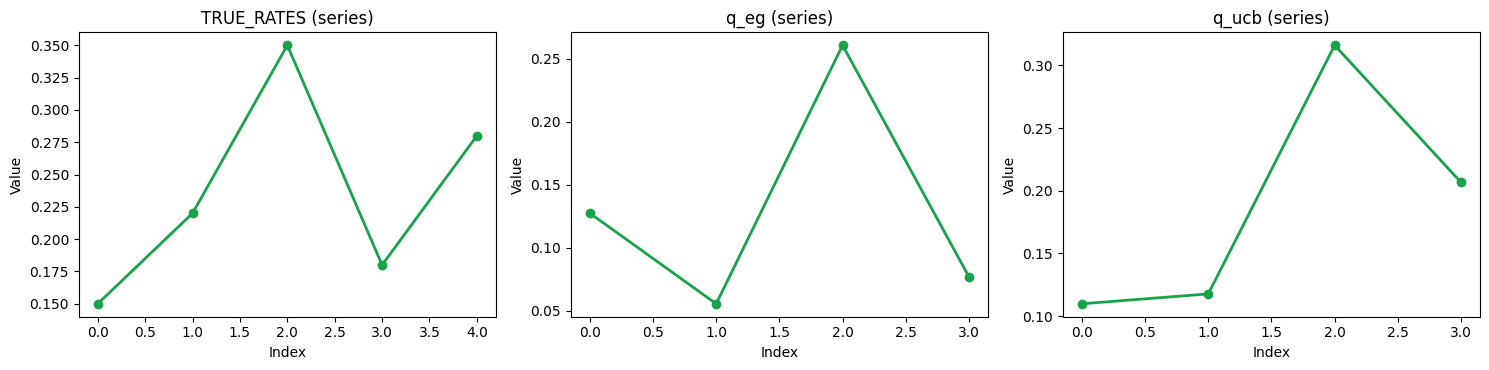

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Import names from a package/module into the notebook kernel namespace.
import numbers
# Import names from a package/module into the notebook kernel namespace.
import numpy as np
# Import names from a package/module into the notebook kernel namespace.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Return a value from this function to its caller.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # Branch: only run the next indented lines when this condition is true.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Return a value from this function to its caller.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Loop header: repeat the indented block for each item in the iterable.
    for item in value.values():
        # Branch: only run the next indented lines when this condition is true.
        if not _is_number(item):
            # Return a value from this function to its caller.
            return None
        # Append one value to a list (mutates the list in place).
        converted.append(float(item))
    # Return a value from this function to its caller.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if array.ndim != dims:
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 1 and not (2 <= array.size <= 200):
        # Return a value from this function to its caller.
        return None
    # Branch: only run the next indented lines when this condition is true.
    if dims == 2 and array.size > 400:
        # Return a value from this function to its caller.
        return None
    # Return a value from this function to its caller.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Assign/update a variable used later in this cell or in other cells.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Loop header: repeat the indented block for each item in the iterable.
for name in search_space:
    # Branch: only run the next indented lines when this condition is true.
    if name in seen or name not in globals() or name in skip_names:
        # Skip the rest of this loop body and jump to the next iteration.
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # Branch: only run the next indented lines when this condition is true.
    if dict_payload is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("dict", name, dict_payload))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # Branch: only run the next indented lines when this condition is true.
    if array_2d is not None:
        # Append one value to a list (mutates the list in place).
        candidates.append(("heatmap", name, array_2d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break
        # Skip the rest of this loop body and jump to the next iteration.
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # Branch: only run the next indented lines when this condition is true.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            continue
        candidates.append(("line", name, array_1d))
        # Branch: only run the next indented lines when this condition is true.
        if len(candidates) == 3:
            # Exit the nearest enclosing loop immediately.
            break

# Branch: only run the next indented lines when this condition is true.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Configure a subplot axis (limits, ticks, labels, or artists).
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_title("Notebook artifact summary")
    # More on the same axes object (limits, ticks, labels, artists).
    ax.set_ylabel("Count")
    # Loop header: repeat the indented block for each item in the iterable.
    for idx, value in enumerate(summary.values()):
        # More on the same axes object (limits, ticks, labels, artists).
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # Branch: only run the next indented lines when this condition is true.
    if len(candidates) == 1:
        # Assign/update a variable used later in this cell or in other cells.
        axes = [axes]

    # Loop header: repeat the indented block for each item in the iterable.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # Branch: only run the next indented lines when this condition is true.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Configure a subplot axis (limits, ticks, labels, or artists).
            ax.bar(range(len(values)), values, color="#2563eb")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticks(range(len(values)))
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (dict)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else-if branch: checked only when previous conditions were false.
        elif kind == "line":
            # More on the same axes object (limits, ticks, labels, artists).
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (series)")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_xlabel("Index")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_ylabel("Value")
        # Else branch: runs when the matching if/elif chain was not taken.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # More on the same axes object (limits, ticks, labels, artists).
            ax.set_title(f"{name} (heatmap)")
            # Configure or update the active Matplotlib Figure object.
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.tight_layout()
    # Call a Matplotlib pyplot helper (figure/axes/plot/show).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can reason about exploration choices and justify them instead of memorizing method names.

**If students remember one idea:** The goal is not to list strategies, but to defend when and why a strategy fits a task.

**Quick check before moving on:**
- Can you explain why your chosen exploration method suits the scenario?
- Can you compare two methods in terms of risk, uncertainty, and data efficiency?

**Bridge to the next step:** After this exercise, students are ready to examine real applications and advanced RL structures in Unit 5.
